In [7]:
# cell1
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import platform
from tqdm import tqdm

# 只设置字体，不设置任何随机种子
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

device = torch.device('cpu')
print(f"✅ 系统: {platform.system()}")
print(f"✅ 无固定种子，确保随机性")

✅ 系统: Darwin
✅ 无固定种子，确保随机性


In [8]:
# cell2
df = pd.read_csv('simulated_icf_clinical_data.csv')

def create_sequences(df, n_history=3):
    sequences, targets, patient_ids = [], [], []
    for pid, group in df.groupby('patient_id'):
        group = group.sort_values('time_step')
        features = group[['icf_total', 'rom', 'vas']].values
        for i in range(len(features) - n_history):
            sequences.append(features[i:i+n_history])
            targets.append(features[i+n_history, 0])
            patient_ids.append(pid)
    return np.array(sequences), np.array(targets), patient_ids

X, y, pids = create_sequences(df, n_history=3)
print(f"数据: X{X.shape}, y{y.shape}")

# 无random_state！
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"训练: {len(X_train)}, 测试: {len(X_test)}")

数据: X(150, 3, 3), y(150,)
训练: 120, 测试: 30


In [9]:
# cell3 
# ==================== 特征标准化（重要！） ====================
# 注意：标准化要在划分后进行，避免数据泄漏

# 重塑为2D进行标准化，再恢复为3D
scaler = StandardScaler()

# 训练集标准化
shape_train = X_train.shape
X_train_2d = X_train.reshape(-1, X_train.shape[-1])  # (样本数*步长, 特征数)
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_train = X_train_2d_scaled.reshape(shape_train)

# 测试集用同样的scaler（只能用transform，不能用fit_transform）
X_test_2d = X_test.reshape(-1, X_test.shape[-1])
X_test_2d_scaled = scaler.transform(X_test_2d)
X_test = X_test_2d_scaled.reshape(X_test.shape)

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # 增加维度
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f"数据标准化完成！")
print(f"训练集X范围: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"训练集y范围: [{y_train.min():.2f}, {y_train.max():.2f}]")

# 在Cell 3末尾添加
print("\n标准化后数据范围检查：")
print(f"X_train ICF列: [{X_train[:,:,0].min():.3f}, {X_train[:,:,0].max():.3f}]")
print(f"y_train: [{y_train.min():.3f}, {y_train.max():.3f}]")

数据标准化完成！
训练集X范围: [-2.35, 2.31]
训练集y范围: [112.00, 200.00]

标准化后数据范围检查：
X_train ICF列: [-1.842, 1.612]
y_train: [112.000, 200.000]


In [10]:
#cell 4:
# ==================== LSTM预测模型 ====================

class ICFPredictorLSTM(nn.Module):
    """
    LSTM多元时序预测模型
    输入: (batch_size, seq_len=3, n_features=3) - 历史3次的icf, rom, vas
    输出: (batch_size, 1) - 预测下一次的icf_total
    """
    def __init__(self, input_size=3, hidden_size=64, num_layers=2):
        super(ICFPredictorLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,      # 3个特征: icf_total, rom, vas
            hidden_size=hidden_size,    # 隐藏层64维
            num_layers=num_layers,      # 2层LSTM
            batch_first=True,           # 批次维度在前
            dropout=0.2                 # 防过拟合
        )
        
        # 全连接输出层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)  # 输出1个预测值（icf_total）
        )
    
    def forward(self, x):
        # LSTM前向传播
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # 取最后一个时间步的输出 (batch, hidden_size)
        last_output = lstm_out[:, -1, :]
        
        # 全连接层预测
        prediction = self.fc(last_output)
        return prediction

# 实例化模型
model = ICFPredictorLSTM(input_size=3, hidden_size=64, num_layers=2).to(device)
print(f"模型结构:\n{model}")
print(f"\n总参数数量: {sum(p.numel() for p in model.parameters()):,}")

模型结构:
ICFPredictorLSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

总参数数量: 53,057


开始训练LSTM模型...


  8%|██████▍                                                                          | 16/200 [00:00<00:01, 155.49it/s]

轮次 [20/200], 平均损失MSE: 9303.7842


 25%|████████████████████▎                                                            | 50/200 [00:00<00:00, 162.75it/s]

轮次 [40/200], 平均损失MSE: 1359.0888


...

轮次 [160/200], 平均损失MSE: 426.4552


 93%|██████████████████████████████████████████████████████████████████████████▍     | 186/200 [00:01<00:00, 165.68it/s]

轮次 [180/200], 平均损失MSE: 348.4134


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 163.72it/s]


轮次 [200/200], 平均损失MSE: 455.2920

✅ 训练完成！


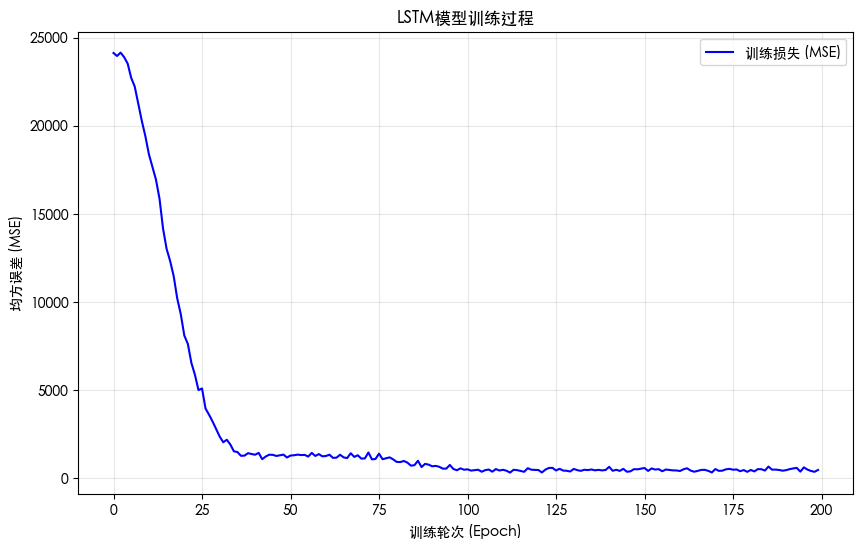


📊 训练效果检查：
最终训练损失: 455.2920
初期训练损失: 24129.6147
损失下降幅度: 98.1%


In [11]:
#cell 5:
# ==================== 模型训练 ====================

# 创建数据加载器（小批量训练）
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差（回归任务）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练循环
num_epochs = 200
train_losses = []

print("开始训练LSTM模型...")
for epoch in tqdm(range(num_epochs)):
    model.train()  # 训练模式
    epoch_losses = []
    
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    # 记录平均损失
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    
    # 每20轮打印一次
    if (epoch + 1) % 20 == 0:
        print(f'轮次 [{epoch+1}/{num_epochs}], 平均损失MSE: {avg_loss:.4f}')

print("\n✅ 训练完成！")

# 绘制训练损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='训练损失 (MSE)', color='blue')
plt.xlabel('训练轮次 (Epoch)')
plt.ylabel('均方误差 (MSE)')
plt.title('LSTM模型训练过程')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 在Cell 5最后添加
print("\n📊 训练效果检查：")
print(f"最终训练损失: {train_losses[-1]:.4f}")
print(f"初期训练损失: {train_losses[0]:.4f}")
print(f"损失下降幅度: {(train_losses[0] - train_losses[-1])/train_losses[0]*100:.1f}%")

# 如果下降幅度<5%，说明模型没学好
if (train_losses[0] - train_losses[-1])/train_losses[0] < 0.05:
    print("⚠️ 警告：损失下降不明显，模型可能欠拟合！")
    print("建议增加训练轮数或调整学习率")

In [12]:
#cell 6:
import os
os.environ['MPLBACKEND'] = 'Agg'  # 完全禁用任何显示

%matplotlib inline
# ==================== 模型评估 ====================
# 预测
model.eval()  # 评估模式
with torch.no_grad():
    y_pred_train = model(X_train_tensor).cpu().numpy()
    y_pred_test = model(X_test_tensor).cpu().numpy()

# 计算MSE和RMSE
mse_train = np.mean((y_train - y_pred_train.flatten())**2)
mse_test = np.mean((y_test - y_pred_test.flatten())**2)
rmse_test = np.sqrt(mse_test)

print(f"📊 模型性能评估：")
print(f"训练集 MSE: {mse_train:.4f}")
print(f"测试集 MSE: {mse_test:.4f}")
print(f"测试集 RMSE: {rmse_test:.4f}")
print(f"测试集平均绝对误差: {np.mean(np.abs(y_test - y_pred_test.flatten())):.4f}")

# ==================== 可视化1：预测值 vs 真实值 ====================
# 保存散点图（不显示）
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=50)
plt.plot([40, 200], [40, 200], 'r--', lw=2,label='完美预测线')
plt.title(f'测试集预测效果\nMSE: {mse_test:.4f} | RMSE: {rmse_test:.4f}', fontsize=14)
plt.xlabel('真实ICF总分', fontsize=12)
plt.ylabel('预测ICF总分', fontsize=12)

# 添加R²分数
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
print("r2=",r2)

plt.savefig('scatter_plot.png', dpi=100)
plt.close()  # 必须关闭，否则会内存泄漏
print("✅ 散点图已保存为 scatter_plot.png")


# ==================== 可视化2：时序预测对比（选3个患者） ====================
import random

# 从所有患者中随机选3个（不依赖测试集划分）
all_pids = df['patient_id'].unique().tolist()
random.shuffle(all_pids)
test_pids = all_pids[:3]
print(f"✅ 随机选中患者: {test_pids}")

plt.figure(figsize=(15, 10))
for idx, pid in enumerate(test_pids):
    # 找到该患者的所有数据
    patient_df = df[df['patient_id'] == pid].sort_values('time_step')
    
    # 生成该患者的预测序列（需要重新跑一遍create_sequences逻辑）
    features = patient_df[['icf_total', 'rom', 'vas']].values
    true_icf = patient_df['icf_total'].values
    time_steps = patient_df['time_step'].values
    
    # 用训练好的模型预测（如果有足够历史数据）
    predictions = []
    pred_times = []
    
    for i in range(3, len(features)):  # 从第4个时间点开始预测（需要前3个）
        hist = features[i-3:i]
        hist_scaled = scaler.transform(hist.reshape(-1, 3)).reshape(1, 3, 3)
        hist_tensor = torch.FloatTensor(hist_scaled).to(device)
        
        with torch.no_grad():
            pred = model(hist_tensor).cpu().numpy()[0][0]
        predictions.append(pred)
        pred_times.append(time_steps[i])
    
    # 绘图
    plt.subplot(3, 1, idx+1)
    plt.plot(time_steps, true_icf, 'bo-', label='真实ICF', markersize=8, linewidth=2)
    if predictions:
        plt.plot(pred_times, predictions, 'rx--', label='预测ICF', markersize=8, linewidth=2)
    plt.xlabel('Time Step (评估次数)', fontsize=10)
    plt.ylabel('ICF总分', fontsize=10)
    plt.title(f'患者 {pid} 康复轨迹预测', fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(40, 200)  # 固定Y轴范围
    plt.xticks(time_steps)
    plt.savefig(f'trajectory_{pid}.png', dpi=100)
    plt.close()
    print(f"✅ 轨迹图已保存: trajectory_{pid}.png")


print("\n✅ 所有评估完成！模型已保存为 'icf_lstm_model.pth'")
torch.save(model.state_dict(), 'icf_lstm_model.pth')

📊 模型性能评估：
训练集 MSE: 60.0214
测试集 MSE: 53.4816
测试集 RMSE: 7.3131
测试集平均绝对误差: 6.4606
r2= 0.9527199487986345
✅ 散点图已保存为 scatter_plot.png
✅ 随机选中患者: ['P030', 'P007', 'P016']
✅ 轨迹图已保存: trajectory_P030.png
✅ 轨迹图已保存: trajectory_P007.png
✅ 轨迹图已保存: trajectory_P016.png

✅ 所有评估完成！模型已保存为 'icf_lstm_model.pth'
